# v3 2nd hidden layer — perturbation sweeps, accuracy

Visualises the **v3L2 factorial** grid: the same experiment as
[the 1st-layer notebook](../1stLayer/result_visualization.ipynb), moved one layer
deeper. A per-pair spike ceiling `relu(count - k)` sets temporal sparsity `a` along
`k`, crossed with a membrane-potential floor setting selectivity `s` (OFF / ON), at
seeds 42/43/44 — now applied to `hidden2` rather than `hidden1`, and measured there
too.

**The grid is not the same shape in the two arms.** Layer 2 in the delay arm fires
about twice as hard as layer 1 (natural `a` of 20.7–30.4 against 3.8–15.5), so the
delay script carries an extra `k = 16` row to anchor the top of the `a` axis
(document 6 §3a). The no-delay arm keeps `k = 1, 2, 4, 8`.

| arm | grid | checkpoints |
|---|---|---|
| no-delay | 4 `k` × 2 floor × 3 seeds | 24 |
| with-delay | **5** `k` × 2 floor × 3 seeds | **30** |

Each panel also carries the **non-sparse baseline** from `FWP_log/` — the
fixed-weight-perturbation network trained with *no sparsity penalty at all*,
perturbed at its own 2nd layer over the same sweeps. It says what an unconstrained
network of this architecture does.

This notebook plots **accuracy**, plus the manipulation check (§3). The scoring, the
regressions on `a` and `s`, and the H1'/H2 verdict live in
[sparse_network_2ndLayer_test_progress_v3.md](../../../docs/progress/sparse_network_2ndLayer_test_progress_v3.md)
and in the `v3_analysis/` scripts.

Every v3L2 point is the **mean over the cell's 3 seeds**; bands and error bars are
the across-seed standard deviation, read from the `per_setup` section of each
results file (the per-seed rows are kept in `per_checkpoint`). The baseline is a
single model per arm, with its own 3 perturbation repeats.

**Encoding.** `k` is an *ordered* variable, so it gets a single-hue ramp
(light → dark as `k` rises), extended to five steps for the delay arm. The floor is
*binary*, so it gets line style rather than a hue. The baseline is not a cell of the
factorial, so it takes neutral ink and a dash-dot line rather than a colour slot.

| perturbation | what it destroys | rate-preserving? | window |
|---|---|---|---|
| relocation | spike placement, count held exactly | yes | `[0, 90)` / `[0, 160)` |
| jitter | spike placement, locally | yes | `[0, 90)` / `[0, 160)` |
| shift | cross-neuron alignment (rigid per-neuron translation) | yes | none — not clipped |
| deletion | spikes themselves — the **general-robustness control** | **no** | none |

The two windows are layer 2's own measured temporal support, per arm; the delay
arm's is nearly twice layer 1's `[0, 88)` because `delay1` sits *upstream* of the
probe site and pushes layer 2's spikes as late as bin 159 (document 6 §2a). Shift and
deletion are deliberately left unclipped: clipping a rigid translation would pile
spikes at the edge and merge them, turning a timing probe into a rate insult.

> **Two caveats on the baseline.**
>
> 1. **The jitter panel is not strictly like-for-like.** The v3L2 jitter sweeps clip
>    jittered spikes to the layer's measured support; the baseline's jitter
>    (`exp_fixed_weight_perturbation/.../jitter_2ndLayer_evalOnly.py`, generated
>    2026-07-15) clips to the full `[0, T-1]` window. Jitter is local, so the
>    artifact is small, but it biases the baseline *downward* relative to the v3L2
>    curves — and more so in the no-delay arm (90 of 200 bins) than the delay arm
>    (160 of 200). Relocation is fine (that baseline was regenerated 2026-07-31 with
>    support-confined destinations, `SUPPORT_BINS = "auto"`), and shift and deletion
>    have no destination window to correct.
> 2. **Unlike at layer 1, the four baseline files agree exactly** on clean accuracy
>    (.584 no-delay, .890 delay), so §2 draws a line rather than a band. The check is
>    made in code rather than assumed.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

# Anchor on exp_sparse_network/ by walking up from wherever the notebook runs,
# so this works from the notebook's own directory or from the repo root.
def find_experiment_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "shd" / "log").is_dir() and (candidate / "sn_data").is_dir():
            return candidate
        nested = candidate / "my_project" / "exp_sparse_network"
        if (nested / "shd" / "log").is_dir():
            return nested
    raise FileNotFoundError("could not locate exp_sparse_network/")

EXP_DIR = find_experiment_root()
FWP_DIR = EXP_DIR / "result_visualization" / "2ndLayer" / "FWP_log"
print(f"experiment root: {EXP_DIR}")
print(f"baseline logs  : {FWP_DIR}")

# (label, folder, v3L2 file stem, sweep key, baseline file template, x-axis label)
PERTURBATIONS = [
    ("relocation", "shd", "shd", "f_sweep",
     "shd_2ndLayer_whole_{arm}_hidden_perturbation_results.json",
     "fraction of spikes relocated  f"),
    ("jitter", "jitter", "jitter", "sigma_sweep",
     "jitter_2ndLayer_whole_{arm}_evalOnly_jitter_sweep_results.json",
     "jitter sigma  (ms)"),
    ("shift", "shift", "shift", "sigma_sweep",
     "shift_2ndLayer_whole_{arm}_evalOnly_shift_sweep_results.json",
     "shift sigma  (ms)"),
    ("deletion", "deletion", "deletion", "pd_sweep",
     "deletion_2ndLayer_whole_{arm}_evalOnly_deletion_sweep_results.json",
     "deletion probability  p_d"),
]
ARMS = [("nodelay", "no-delay arm"), ("delay", "with-delay arm")]

CHANCE = 1.0 / 20

# Layer 2's unconstrained firing, measured on the 27 v1 checkpoints
# (document 6 §2a) -- the reference the ceiling is pushing down from.
NATURAL_A = {"nodelay": (7.49, 12.46), "delay": (20.71, 30.44)}
# Observational rho(a, s) at layer 2, same measurement pass. Positive here, where
# layer 1's was -0.943 / -0.455: this is the confound the factorial must break.
OBSERVED_RHO = {"nodelay": 0.829, "delay": 0.427}
SUPPORT_BINS = {"nodelay": 90, "delay": 160}

# `k` is ordered -> one-hue ordinal ramp, light to dark, five steps because the
# delay arm carries k = 16. The floor is binary -> line style, not hue.
K_COLOURS = {1.0: "#a3c8f2", 2.0: "#6ea6e9", 4.0: "#3d84d9",
             8.0: "#1f5fae", 16.0: "#123a6b"}
FLOOR_STYLE = {0.0: dict(linestyle="--", marker="o", markerfacecolor="white"),
               1.0: dict(linestyle="-", marker="o")}
FLOOR_COLOUR = {0.0: "#2a78d6", 1.0: "#eb6834"}

INK, INK_MUTED, GRID = "#0b0b0b", "#52514e", "#d8d7d2"

# The non-sparse baseline is a reference, not a series: neutral ink, dash-dot.
BASELINE_STYLE = dict(color=INK, linestyle="-.", marker="s", markersize=4.5,
                      linewidth=2.2, zorder=5)


def load_results(arm: str, folder: str, stem: str) -> dict:
    """Return the whole v3L2 results file for one arm and one perturbation."""
    path = EXP_DIR / folder / "log" / f"sparse_whole_{arm}_v3L2_{stem}_eval.json"
    return json.loads(path.read_text())


def load_per_setup(arm: str, folder: str, stem: str) -> dict:
    """Return the seed-averaged v3L2 rows for one arm and one perturbation."""
    return load_results(arm, folder, stem)["per_setup"]


def load_baseline(arm: str, template: str) -> dict:
    """Return the non-sparse sweep: {grid point (float) -> (mean, std)}."""
    raw = json.loads((FWP_DIR / template.format(arm=arm)).read_text())
    return {float(point): (entry["mean"], entry["std"])
            for point, entry in raw.items()}


def k_levels(arm: str) -> list:
    """Return the ceiling levels actually present in this arm's grid."""
    rows = load_per_setup(arm, "shd", "shd").values()
    return sorted({row["ceiling_k"] for row in rows})


def style_axis(axis) -> None:
    """Recessive grid and spines, so the data carries the ink."""
    axis.grid(True, color=GRID, linewidth=0.6, alpha=0.9)
    axis.set_axisbelow(True)
    for side in ("top", "right"):
        axis.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        axis.spines[side].set_color(GRID)
    axis.tick_params(colors=INK_MUTED, labelsize=9)


# Check that all eight v3L2 files and all eight baseline files are present, and
# that every cell really carries three seeds.
for arm, _ in ARMS:
    print(f"{arm}  (target layer 2, support [0, {SUPPORT_BINS[arm]}))")
    for label, folder, stem, field, template, _ in PERTURBATIONS:
        results = load_results(arm, folder, stem)
        rows = results["per_setup"]
        layers = {row["target_layer"] for row in results["per_checkpoint"].values()}
        seeds = {row["n_seeds"] for row in rows.values()}
        baseline = load_baseline(arm, template)
        print(f"  {label:<11} v3L2: {len(rows)} setups, "
              f"{len(results['per_checkpoint'])} checkpoints, seeds {seeds}, "
              f"target_layer {layers}  |  baseline: {len(baseline)} points, "
              f"clean {baseline[min(baseline)][0]:.3f}")

experiment root: d:\IC_2025\IRP\workspace\my_project\exp_sparse_network
baseline logs  : d:\IC_2025\IRP\workspace\my_project\exp_sparse_network\result_visualization\2ndLayer\FWP_log
nodelay  (target layer 2, support [0, 90))
  relocation  v3L2: 8 setups, 24 checkpoints, seeds {3}, target_layer {2}  |  baseline: 11 points, clean 0.584
  jitter      v3L2: 8 setups, 24 checkpoints, seeds {3}, target_layer {2}  |  baseline: 7 points, clean 0.584
  shift       v3L2: 8 setups, 24 checkpoints, seeds {3}, target_layer {2}  |  baseline: 7 points, clean 0.584
  deletion    v3L2: 8 setups, 24 checkpoints, seeds {3}, target_layer {2}  |  baseline: 5 points, clean 0.584
delay  (target layer 2, support [0, 160))
  relocation  v3L2: 10 setups, 30 checkpoints, seeds {3}, target_layer {2}  |  baseline: 11 points, clean 0.890
  jitter      v3L2: 10 setups, 30 checkpoints, seeds {3}, target_layer {2}  |  baseline: 7 points, clean 0.890
  shift       v3L2: 10 setups, 30 checkpoints, seeds {3}, target_laye

## 1. Accuracy against perturbation magnitude

Rows are the two arms, columns the four perturbations. All eight panels share one
y-axis so the arms can be compared directly — the no-delay arm simply starts much
lower.

Reading the panels: the **spread between the coloured curves** is what the factorial
is about, and **the gap to the black baseline** is what the sparsity penalty cost.
A panel where the coloured curves lie on top of each other says the perturbation does
not distinguish the cells.

Note that at layer 2 the second reading is not the one it was at layer 1 — the
probe found that constraining layer 2 costs far less accuracy than constraining
layer 1 did (document 6, probe result 3), so the coloured curves are expected to
start at or above the baseline rather than below it.

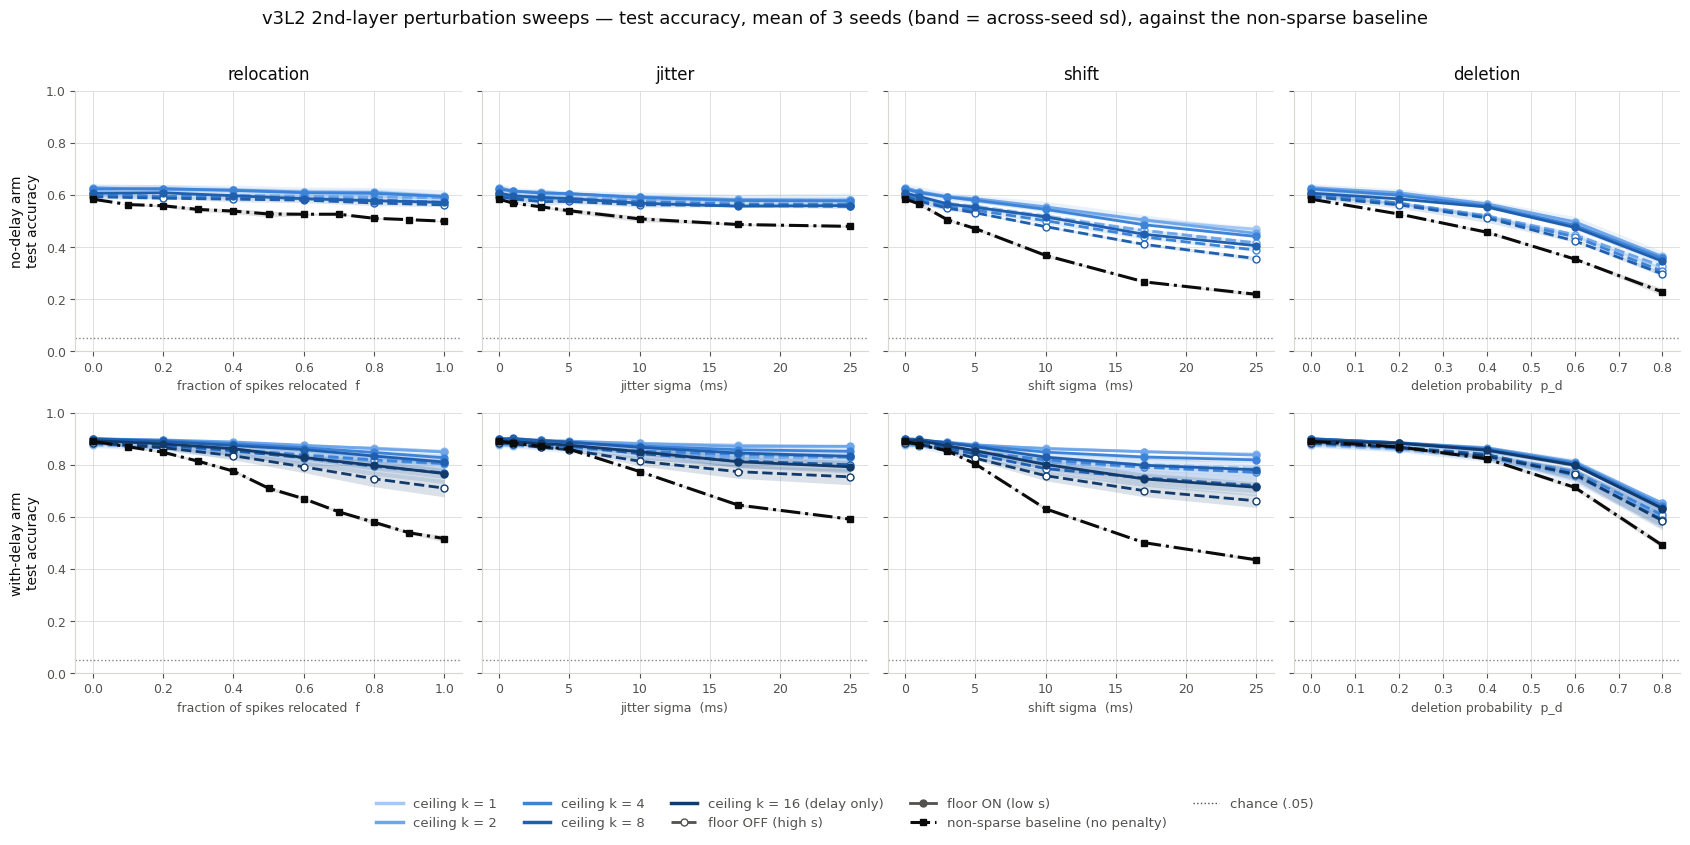

In [2]:
figure, axes = plt.subplots(2, 4, figsize=(17, 8), sharey=True)

for row, (arm, arm_label) in enumerate(ARMS):
    for col, (label, folder, stem, field, template, xlabel) in enumerate(PERTURBATIONS):
        axis = axes[row][col]
        for entry in load_per_setup(arm, folder, stem).values():
            grid = [float(point) for point in entry[field]]
            means = np.array([entry[field][p]["mean"] for p in entry[field]])
            stds = np.array([entry[field][p]["std"] for p in entry[field]])
            colour = K_COLOURS[entry["ceiling_k"]]
            axis.plot(grid, means, color=colour, linewidth=2, markersize=5,
                      markeredgecolor=colour, **FLOOR_STYLE[entry["floor_strength"]])
            axis.fill_between(grid, means - stds, means + stds,
                              color=colour, alpha=0.15, linewidth=0)

        baseline = load_baseline(arm, template)
        points = sorted(baseline)
        base_means = np.array([baseline[p][0] for p in points])
        base_stds = np.array([baseline[p][1] for p in points])
        axis.plot(points, base_means, **BASELINE_STYLE)
        axis.fill_between(points, base_means - base_stds, base_means + base_stds,
                          color=INK, alpha=0.12, linewidth=0, zorder=4)

        axis.axhline(CHANCE, color=INK_MUTED, linewidth=1, linestyle=":", alpha=0.7)
        style_axis(axis)
        axis.set_xlabel(xlabel, fontsize=9, color=INK_MUTED)
        if col == 0:
            axis.set_ylabel(f"{arm_label}\ntest accuracy", fontsize=10, color=INK)
        if row == 0:
            axis.set_title(label, fontsize=12, color=INK, pad=8)

axes[0][0].set_ylim(0.0, 1.0)

handles = [plt.Line2D([], [], color=colour, linewidth=2.5,
                      label=f"ceiling k = {k:g}" + (" (delay only)" if k == 16 else ""))
           for k, colour in K_COLOURS.items()]
handles += [
    plt.Line2D([], [], color=INK_MUTED, linewidth=2, linestyle="--", marker="o",
               markerfacecolor="white", markersize=5, label="floor OFF (high s)"),
    plt.Line2D([], [], color=INK_MUTED, linewidth=2, linestyle="-", marker="o",
               markersize=5, label="floor ON (low s)"),
    plt.Line2D([], [], label="non-sparse baseline (no penalty)", **BASELINE_STYLE),
    plt.Line2D([], [], color=INK_MUTED, linewidth=1, linestyle=":",
               label="chance (.05)"),
]
figure.legend(handles=handles, loc="lower center", ncol=5, frameon=False,
              fontsize=9.5, labelcolor=INK_MUTED, bbox_to_anchor=(0.5, -0.06))
figure.suptitle("v3L2 2nd-layer perturbation sweeps — test accuracy, "
                "mean of 3 seeds (band = across-seed sd), against the "
                "non-sparse baseline", fontsize=13, color=INK)
figure.tight_layout(rect=(0, 0.08, 1, 0.97))
plt.show()

## 2. Clean accuracy across the grid

The unperturbed accuracy each curve above starts from. Worth reading before any
perturbation result: a normalised damage score divides by this number, so a cell
whose clean accuracy is unusual will move the score for reasons that have nothing to
do with timing.

The dash-dot line is the non-sparse network's clean accuracy. The code checks
whether the four baseline files agree; if they disagree it draws the spread as a
band, exactly as the 1st-layer notebook has to.

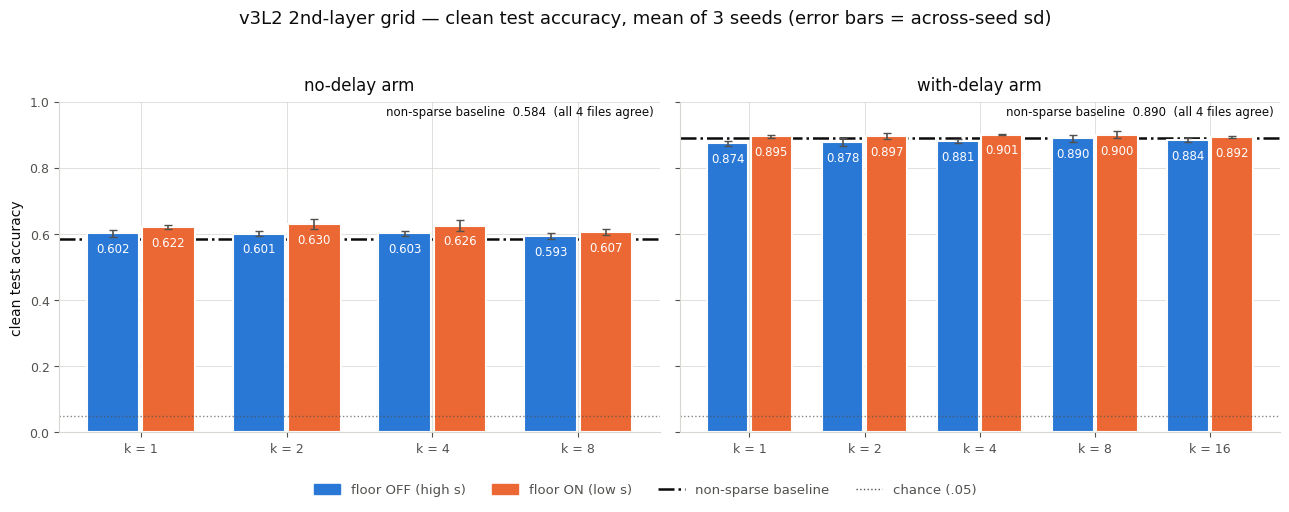

In [3]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
width = 0.36

for col, (arm, arm_label) in enumerate(ARMS):
    axis = axes[col]
    per_setup = load_per_setup(arm, "shd", "shd")
    levels = k_levels(arm)
    positions = np.arange(len(levels))

    # Non-sparse reference: every baseline file's own clean accuracy.
    clean_baselines = [load_baseline(arm, template)[0.0][0]
                       for *_, template, _ in PERTURBATIONS]
    low, high = min(clean_baselines), max(clean_baselines)
    if high - low > 1e-9:
        axis.axhspan(low, high, color=INK, alpha=0.10, zorder=0)
        caption = f"non-sparse baseline  {low:.3f}-{high:.3f}"
    else:
        caption = f"non-sparse baseline  {low:.3f}  (all 4 files agree)"
    axis.axhline(float(np.mean(clean_baselines)), color=INK, linestyle="-.",
                 linewidth=1.8, zorder=1)
    # Caption in the corner, not on the line: here the bars sit *above* the
    # baseline, so a label anchored to it would land on top of them.
    axis.text(0.99, 0.99, caption, transform=axis.transAxes, ha="right",
              va="top", fontsize=8.5, color=INK)

    for index, floor in enumerate([0.0, 1.0]):
        rows = [per_setup[f"k{k:g}_floor{floor:g}"] for k in levels]
        means = [row["clean_acc"] for row in rows]
        errs = [row["clean_acc_std"] for row in rows]
        offset = (index - 0.5) * (width + 0.02)
        axis.bar(positions + offset, means, width, yerr=errs, capsize=3,
                 color=FLOOR_COLOUR[floor], edgecolor="#fcfcfb", linewidth=1.5,
                 error_kw=dict(ecolor=INK_MUTED, lw=1.2), zorder=2)
        # Values sit inside the bar, so they cannot collide with the baseline.
        for position, value in zip(positions + offset, means):
            axis.text(position, value - 0.028, f"{value:.3f}", ha="center",
                      va="top", fontsize=8.5, color="#ffffff", zorder=3)

    axis.axhline(CHANCE, color=INK_MUTED, linewidth=1, linestyle=":", alpha=0.7)
    axis.set_xticks(positions)
    axis.set_xticklabels([f"k = {k:g}" for k in levels])
    style_axis(axis)
    axis.set_title(arm_label, fontsize=12, color=INK, pad=8)
    if col == 0:
        axis.set_ylabel("clean test accuracy", fontsize=10, color=INK)

axes[0].set_ylim(0.0, 1.0)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=FLOOR_COLOUR[0.0], label="floor OFF (high s)"),
    plt.Rectangle((0, 0), 1, 1, color=FLOOR_COLOUR[1.0], label="floor ON (low s)"),
    plt.Line2D([], [], color=INK, linestyle="-.", linewidth=1.8,
               label="non-sparse baseline"),
    plt.Line2D([], [], color=INK_MUTED, linewidth=1, linestyle=":",
               label="chance (.05)"),
]
figure.legend(handles=handles, loc="lower center", ncol=4, frameon=False,
              fontsize=9.5, labelcolor=INK_MUTED, bbox_to_anchor=(0.5, -0.06))
figure.suptitle("v3L2 2nd-layer grid — clean test accuracy, mean of 3 seeds "
                "(error bars = across-seed sd)", fontsize=13, color=INK)
figure.tight_layout(rect=(0, 0.02, 1, 0.94))
plt.show()

## 3. Did the manipulation work? — `a`, `s`, and their correlation

The accuracy panels are only interpretable if the two knobs did what they were built
to do: the ceiling moves `a` (spikes per **active** neuron) and the floor moves `s`
(silent fraction), *independently*. This is the design acceptance check of
document 6, and it is the reason the factorial exists at all.

Three things to read:

- **left** — `a` against `k`, one line per floor setting. The grey band is layer 2's
  *unconstrained* firing measured on the v1 checkpoints (7.49–12.46 no-delay,
  20.71–30.44 delay). The distance from band to curve is how hard the ceiling bit;
  the span of the curve is the row axis the `β_a` regression has to work with, and it
  was document 5's binding limitation.
- **middle** — `s` against `k`. The two floor levels should be widely separated and
  each roughly flat in `k`: that is criteria 1 and 2 of the probe, on the real grid.
- **right** — the joint distribution, one point per checkpoint. `ρ(a, s)` printed
  here is the acceptance number, and it is read against the **observational**
  baseline of **+0.829** (no-delay) and **+0.427** (delay) — layer 2's own confound,
  which runs the *opposite* way to layer 1's −0.943 / −0.455. Acceptance is
  |ρ| < 0.5.

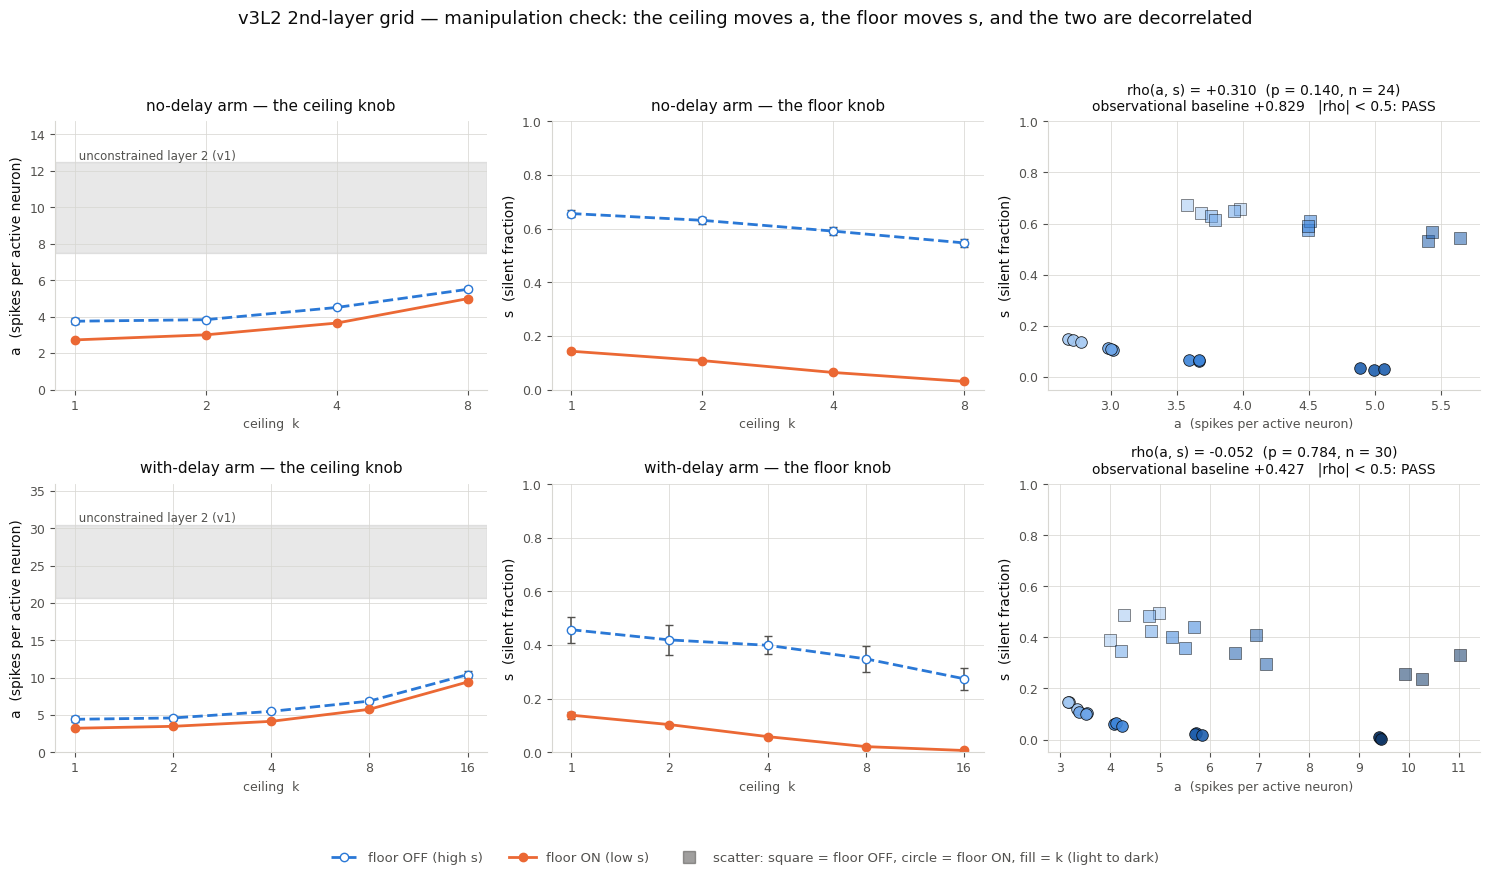

In [4]:
def pearson(x: np.ndarray, y: np.ndarray) -> tuple:
    """Return (r, two-sided p) for a Pearson correlation, via scipy if available."""
    try:
        from scipy.stats import pearsonr
        r, p = pearsonr(x, y)
        return float(r), float(p)
    except ImportError:                      # p is optional; r is not
        return float(np.corrcoef(x, y)[0, 1]), float("nan")


figure, axes = plt.subplots(2, 3, figsize=(15, 8.5))

for row, (arm, arm_label) in enumerate(ARMS):
    per_setup = load_per_setup(arm, "shd", "shd")
    per_checkpoint = load_results(arm, "shd", "shd")["per_checkpoint"]
    levels = k_levels(arm)

    # --- left and middle: the two knobs against k, per floor setting -----------
    for statistic, axis, ylabel in [
            ("spikes_per_active_neuron", axes[row][0], "a  (spikes per active neuron)"),
            ("silent_fraction", axes[row][1], "s  (silent fraction)")]:
        for floor in (0.0, 1.0):
            rows = [per_setup[f"k{k:g}_floor{floor:g}"] for k in levels]
            means = np.array([row[statistic] for row in rows])
            errs = np.array([row[f"{statistic}_std"] for row in rows])
            axis.errorbar(levels, means, yerr=errs, capsize=3, linewidth=2,
                          markersize=6, color=FLOOR_COLOUR[floor],
                          ecolor=INK_MUTED, elinewidth=1.1,
                          **FLOOR_STYLE[floor])
        axis.set_xscale("log", base=2)
        axis.set_xticks(levels)
        axis.set_xticklabels([f"{k:g}" for k in levels])
        axis.set_xlabel("ceiling  k", fontsize=9, color=INK_MUTED)
        axis.set_ylabel(ylabel, fontsize=10, color=INK)
        style_axis(axis)

    natural_low, natural_high = NATURAL_A[arm]
    axes[row][0].axhspan(natural_low, natural_high, color=INK, alpha=0.09, zorder=0)
    axes[row][0].text(levels[0], natural_high, " unconstrained layer 2 (v1)",
                      ha="left", va="bottom", fontsize=8.5, color=INK_MUTED)
    axes[row][0].set_ylim(0, natural_high * 1.18)
    axes[row][1].set_ylim(0, 1.0)

    # --- right: the joint distribution, one point per checkpoint --------------
    axis = axes[row][2]
    activity = np.array([row["spikes_per_active_neuron"]
                         for row in per_checkpoint.values()])
    silent = np.array([row["silent_fraction"] for row in per_checkpoint.values()])
    for row_data in per_checkpoint.values():
        axis.scatter(row_data["spikes_per_active_neuron"], row_data["silent_fraction"],
                     s=70, color=K_COLOURS[row_data["ceiling_k"]],
                     marker="o" if row_data["floor_strength"] else "s",
                     edgecolor=INK, linewidth=0.6,
                     alpha=0.9 if row_data["floor_strength"] else 0.55, zorder=3)
    r_value, p_value = pearson(activity, silent)
    axis.set_xlabel("a  (spikes per active neuron)", fontsize=9, color=INK_MUTED)
    axis.set_ylabel("s  (silent fraction)", fontsize=10, color=INK)
    axis.set_ylim(-0.05, 1.0)
    verdict = "PASS" if abs(r_value) < 0.5 else "FAIL"
    axis.set_title(f"rho(a, s) = {r_value:+.3f}  (p = {p_value:.3f}, "
                   f"n = {len(activity)})\nobservational baseline "
                   f"{OBSERVED_RHO[arm]:+.3f}   |rho| < 0.5: {verdict}",
                   fontsize=10, color=INK, pad=8)
    style_axis(axis)

    axes[row][0].set_title(f"{arm_label} — the ceiling knob", fontsize=11,
                           color=INK, pad=8)
    axes[row][1].set_title(f"{arm_label} — the floor knob", fontsize=11,
                           color=INK, pad=8)

handles = [
    plt.Line2D([], [], color=FLOOR_COLOUR[0.0], linewidth=2, linestyle="--",
               marker="o", markerfacecolor="white", label="floor OFF (high s)"),
    plt.Line2D([], [], color=FLOOR_COLOUR[1.0], linewidth=2, linestyle="-",
               marker="o", label="floor ON (low s)"),
    plt.Line2D([], [], color=INK_MUTED, linestyle="none", marker="s",
               markersize=8, alpha=0.55,
               label="scatter: square = floor OFF, circle = floor ON, "
                     "fill = k (light to dark)"),
]
figure.legend(handles=handles, loc="lower center", ncol=3, frameon=False,
              fontsize=9.5, labelcolor=INK_MUTED, bbox_to_anchor=(0.5, -0.04))
figure.suptitle("v3L2 2nd-layer grid — manipulation check: the ceiling moves a, "
                "the floor moves s, and the two are decorrelated",
                fontsize=13, color=INK)
figure.tight_layout(rect=(0, 0.04, 1, 0.95))
plt.show()

## 4. The same numbers as a table

Kept so the figures are never the only way to read the result, and so exact values
can be quoted without measuring pixels. `over-k` is the fraction of neuron–sample
pairs still exceeding the ceiling — document 6's one residual limitation is that the
ceiling leaks more at layer 2 than at layer 1, and this column is where that shows.
The `BASELINE` row of each arm is the non-sparse network at the same endpoints.

In [5]:
header = (f"{'arm':<15}{'setup':<12}{'clean acc':>16}{'a':>7}{'s':>8}{'over-k':>9}"
          f"{'reloc(1)':>10}{'jit(25)':>9}{'shift(25)':>10}{'del(.8)':>9}")
print(header)
print("-" * len(header))

for arm, arm_label in ARMS:
    per_setup = load_per_setup(arm, "shd", "shd")
    sweeps = {label: load_per_setup(arm, folder, stem)
              for label, folder, stem, _, _, _ in PERTURBATIONS}
    for tag, entry in per_setup.items():
        endpoints = []
        for label, _, _, field, _, _ in PERTURBATIONS:
            sweep = sweeps[label][tag][field]
            endpoints.append(sweep[list(sweep)[-1]]["mean"])
        clean = f"{entry['clean_acc']:.3f}+-{entry['clean_acc_std']:.3f}"
        print(f"{arm_label:<15}{tag:<12}{clean:>16}"
              f"{entry['spikes_per_active_neuron']:>7.2f}"
              f"{entry['silent_fraction']:>8.3f}"
              f"{entry['over_k_fraction']:>9.3f}"
              f"{endpoints[0]:>10.3f}{endpoints[1]:>9.3f}"
              f"{endpoints[2]:>10.3f}{endpoints[3]:>9.3f}")

    base_endpoints, base_cleans = [], []
    for label, _, _, _, template, _ in PERTURBATIONS:
        baseline = load_baseline(arm, template)
        base_cleans.append(baseline[0.0][0])
        base_endpoints.append(baseline[max(baseline)][0])
    if max(base_cleans) - min(base_cleans) > 1e-9:
        clean = (f"{np.mean(base_cleans):.3f}"
                 f"({min(base_cleans):.3f}-{max(base_cleans):.3f})")
    else:
        clean = f"{base_cleans[0]:.3f}"
    print(f"{arm_label:<15}{'BASELINE':<12}{clean:>16}{'--':>7}{'--':>8}{'--':>9}"
          f"{base_endpoints[0]:>10.3f}{base_endpoints[1]:>9.3f}"
          f"{base_endpoints[2]:>10.3f}{base_endpoints[3]:>9.3f}")
    print()

arm            setup              clean acc      a       s   over-k  reloc(1)  jit(25) shift(25)  del(.8)
---------------------------------------------------------------------------------------------------------
no-delay arm   k1_floor0       0.602+-0.011   3.75   0.656    0.258     0.589    0.581     0.416    0.321
no-delay arm   k1_floor1       0.622+-0.006   2.72   0.143    0.586     0.592    0.579     0.468    0.364
no-delay arm   k2_floor0       0.601+-0.008   3.83   0.631    0.207     0.589    0.579     0.416    0.326
no-delay arm   k2_floor1       0.630+-0.015   3.00   0.108    0.430     0.595    0.580     0.453    0.364
no-delay arm   k4_floor0       0.603+-0.008   4.50   0.591    0.154     0.572    0.565     0.389    0.307
no-delay arm   k4_floor1       0.626+-0.016   3.65   0.064    0.256     0.594    0.577     0.441    0.356
no-delay arm   k8_floor0       0.593+-0.010   5.50   0.547    0.088     0.562    0.556     0.356    0.297
no-delay arm   k8_floor1       0.607+-0.009   